Import Libraries

Uses NumPy, Matplotlib, and TensorFlow/Keras for data handling, visualization, and deep learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

Load the datset

In [2]:
data_train_path = '/content/drive/MyDrive/cnn/Fruits_Vegetables/train'
data_test_path = '/content/drive/MyDrive/cnn/Fruits_Vegetables/test'
data_val_path = '/content/drive/MyDrive/cnn/Fruits_Vegetables/validation'

In [3]:
img_width = 180
img_height =180

In [4]:
data_train = tf.keras.utils.image_dataset_from_directory(
    data_train_path,
    shuffle=True,
    image_size=(img_width, img_height),
    batch_size=32,
    validation_split=False)

Found 3115 files belonging to 36 classes.


In [5]:
data_view = data_train.class_names

In [6]:
data_view

['apple',
 'banana',
 'beetroot',
 'bell pepper',
 'cabbage',
 'capsicum',
 'carrot',
 'cauliflower',
 'chilli pepper',
 'corn',
 'cucumber',
 'eggplant',
 'garlic',
 'ginger',
 'grapes',
 'jalepeno',
 'kiwi',
 'lemon',
 'lettuce',
 'mango',
 'onion',
 'orange',
 'paprika',
 'pear',
 'peas',
 'pineapple',
 'pomegranate',
 'potato',
 'raddish',
 'soy beans',
 'spinach',
 'sweetcorn',
 'sweetpotato',
 'tomato',
 'turnip',
 'watermelon']

In [7]:
data_val = tf.keras.utils.image_dataset_from_directory(data_val_path,
                                                       image_size=(img_height,img_width),
                                                       batch_size=32,
                                                        shuffle=False,
                                                       validation_split=False)

Found 351 files belonging to 36 classes.


In [8]:
data_test = tf.keras.utils.image_dataset_from_directory(
data_test_path,
    image_size=(img_height,img_width),
    shuffle=False,
    batch_size=32,
    validation_split=False
)

Found 359 files belonging to 36 classes.


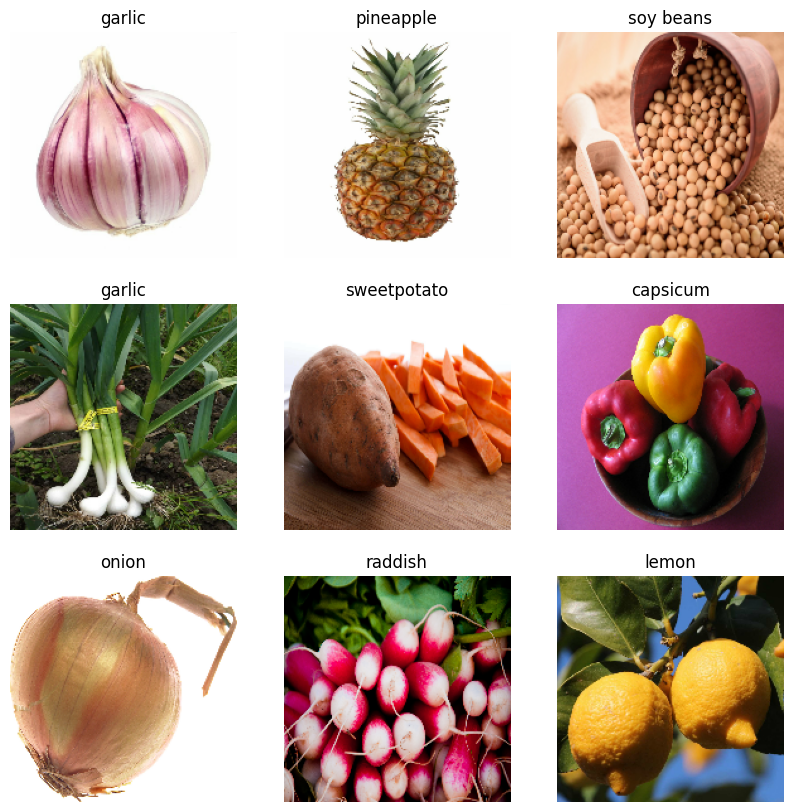

In [10]:
plt.figure(figsize=(10,10))
for image, labels in data_train.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(data_view[labels[i]])
        plt.axis('off')

In [11]:
from tensorflow.keras.models import Sequential

In [12]:
data_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

Build CNN Model

**Rescaling Layer**: Normalizes pixel values from 0–255 to 0–1.
**Convolution Layers**: Extract image features such as edges, textures, and shapes.
**MaxPooling Layers**: Reduce image dimensions while retaining important features.
**Flatten Layer:** Converts feature maps into a 1D vector.
**Dropout (0.2):** Acts as regularization to reduce overfitting.
**Dense Layers:** Perform final classification into fruit/vegetable categories.

In [13]:
model = Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,3, padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(128),
    layers.Dense(len(data_view))

])

Compile the Model

Uses the Adam optimizer.
Uses Sparse Categorical Crossentropy loss for multiclass classification.
Tracks accuracy during training.

In [14]:
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

Train the Model

Trains the CNN for 25 epochs using training data.
Evaluates performance on the validation dataset after each epoch.

In [15]:
epochs_size = 25
history = model.fit(data_train, validation_data=data_val, epochs=epochs_size)

Epoch 1/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 602s 6s/step - accuracy: 0.1101 - loss: 3.2939 - val_accuracy: 0.2792 - val_loss: 2.5365
Epoch 2/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 66s 677ms/step - accuracy: 0.3034 - loss: 2.4714 - val_accuracy: 0.6097 - val_loss: 1.5867
Epoch 3/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 69s 707ms/step - accuracy: 0.4754 - loss: 1.8543 - val_accuracy: 0.7322 - val_loss: 0.9909
Epoch 4/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 83s 717ms/step - accuracy: 0.6636 - loss: 1.1846 - val_accuracy: 0.8689 - val_loss: 0.5655
Epoch 5/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 67s 686ms/step - accuracy: 0.8061 - loss: 0.6901 - val_accuracy: 0.9288 - val_loss: 0.3631
Epoch 6/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 83s 699ms/step - accuracy: 0.8831 - loss: 0.4203 - val_accuracy: 0.9316 - val_loss: 0.3637
Epoch 7/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 81s 692ms/step - accuracy: 0.9307 - loss: 0.2671 - val_accuracy: 0.9430 - val_loss: 0.2951
Epoch 8/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 65s 662ms/step - accuracy: 0.9551 - loss: 0.1855 - val_accura

Plot Performance

Displays graphs for:
Training vs Validation Accuracy
Training vs Validation Loss

Text(0.5, 1.0, 'Loss')

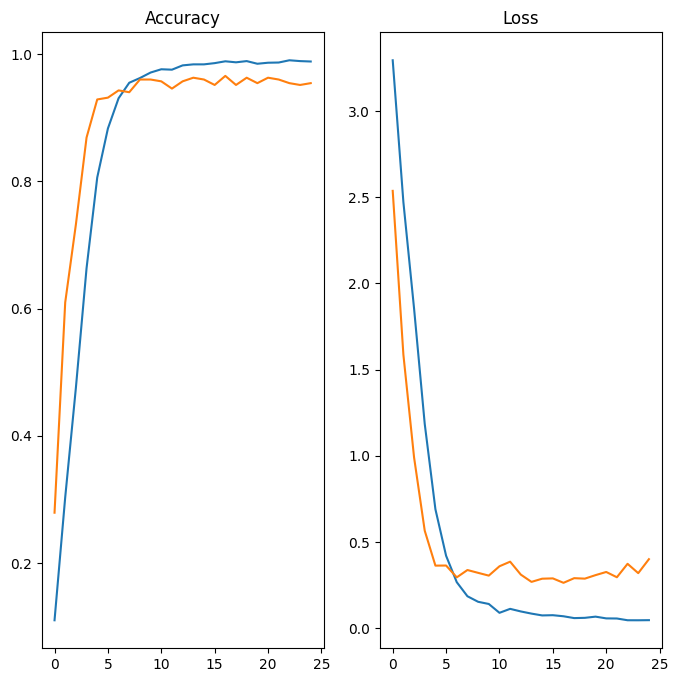

In [16]:
epochs_range = range(epochs_size)
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(epochs_range,history.history['accuracy'],label = 'Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'],label = 'Validation Accuracy')
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range,history.history['loss'],label = 'Training Loss')
plt.plot(epochs_range, history.history['val_loss'],label = 'Validation Loss')
plt.title('Loss')